Saving aibd-datset.xlsx to aibd-datset (1).xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

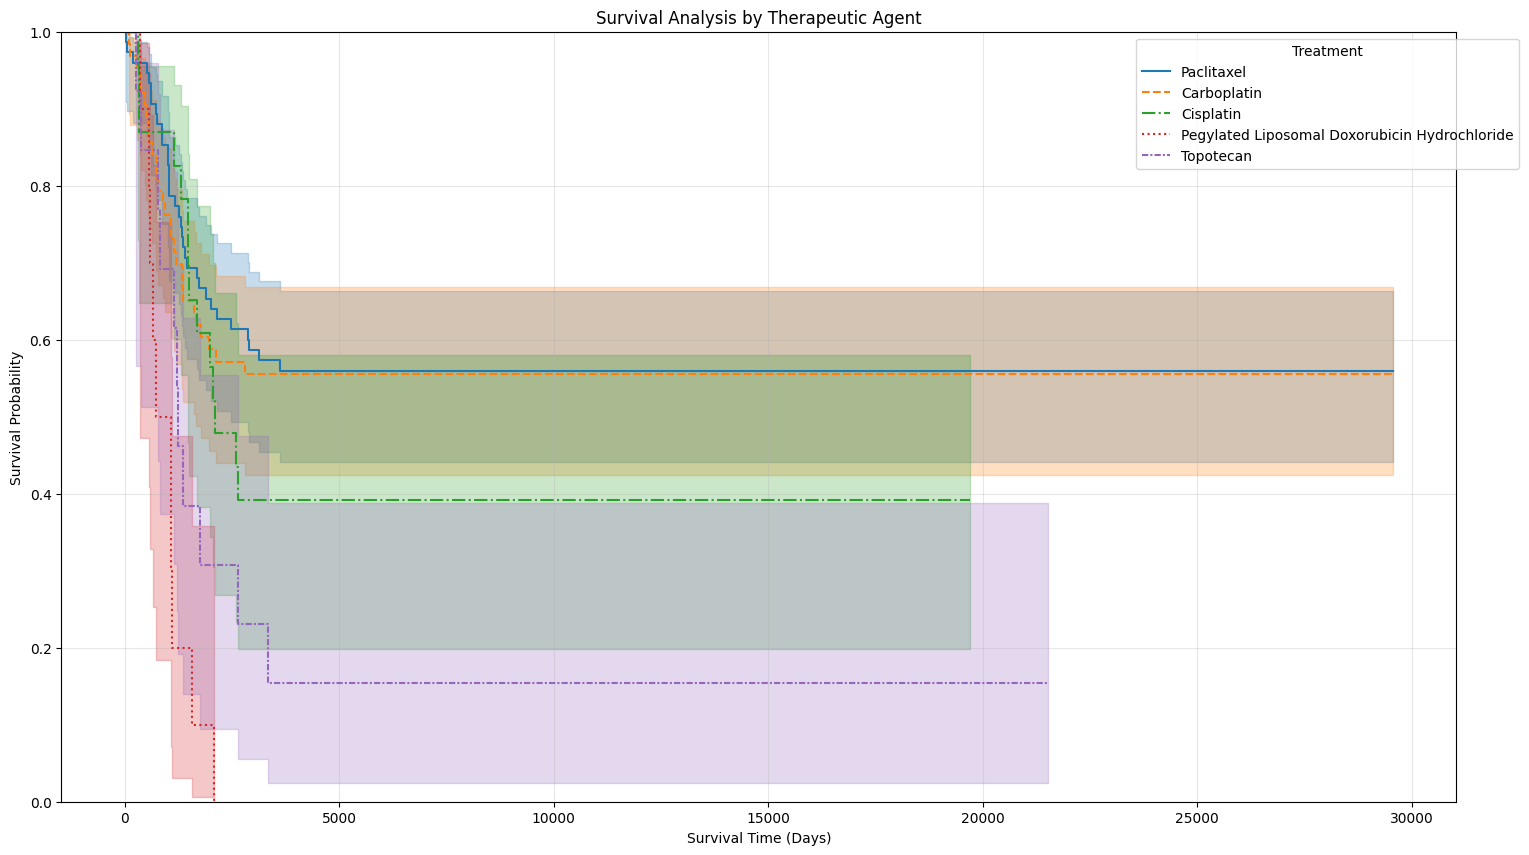

In [ ]:
# Install required packages (for Google Colab)
!pip install openpyxl lifelines
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Load data using ACTUAL COLUMN NAMES from your dataset
df = pd.read_excel('aibd-datset.xlsx', sheet_name='Sheet1', engine='openpyxl')

# Filter for ovarian cancer cases
df = df[df['diagnoses.primary_diagnosis'].str.contains(
    'serous cystadenocarcinoma',
    case=False,
    na=False
)]

# Select relevant columns from YOUR DATASET
cols = [
    'demographic.days_to_death',
    'demographic.vital_status',
    'demographic.age_at_index', # Add age_at_index to the list of columns
    'diagnoses.tumor_grade',
    'diagnoses.figo_stage',
    'pathology_details.residual_tumor_measurement',
    'treatments.therapeutic_agents'
]
df = df[cols].copy()

# Clean missing values
df.replace([
    "'--", "--", "unknown", "Not Reported",
    " ", "", "nan", "NaN", np.nan
], pd.NA, inplace=True)

# Handle censored data using age_at_index as proxy for follow-up time
df['survival_time'] = np.where(
    df['demographic.vital_status'] == 'Dead',
    pd.to_numeric(df['demographic.days_to_death'], errors='coerce'),
    pd.to_numeric(df['demographic.age_at_index'], errors='coerce') * 365  # Convert years to days
)
df['event'] = (df['demographic.vital_status'] == 'Dead').astype(int)

# Tumor Grade Encoding (using your specified rules)
grade_map = {
    'G1':2, 'G2':2, 'G3':3, 'G4':2, 'GX':2, 'GB':2
}
df['grade'] = (
    df['diagnoses.tumor_grade']
    .str.upper().str.strip()
    .map(grade_map)
)

# FIGO Stage Encoding (1/2/4 → 4, 3 → 3)
def encode_figo(stage):
    stage = str(stage).upper()
    if 'III' in stage:
        return 3
    else:
        return 4
df['stage'] = df['diagnoses.figo_stage'].apply(encode_figo)

# Tumor Size Encoding (based on residual tumor measurements)
def encode_residual(measurement):
    measurement = str(measurement).upper().replace(" ", "")

    if 'NOMACROSCOPIC' in measurement:
        return 0
    elif any(x in measurement for x in ['1-10']):
        return 1
    elif any(x in measurement for x in ['11-20', '>20' ]):
        return 2
    return pd.NA
df['size'] = df['pathology_details.residual_tumor_measurement'].apply(encode_residual)

# Filter therapeutic agents (case-insensitive partial matches)
selected_agents = [
    'Paclitaxel',
    'Carboplatin',
    'Cisplatin',
    'Pegylated Liposomal Doxorubicin Hydrochloride',
    'Topotecan'
]
mask = df['treatments.therapeutic_agents'].str.contains(
    '|'.join(selected_agents),
    case=False,
    na=False
)
df = df[mask].copy()

# Final cleaning
df = df.dropna(subset=['survival_time', 'event', 'grade', 'stage', 'size'])

# Final cleaning
# Assign the result of dropna to df_final
df_final = df.dropna(subset=['survival_time', 'event', 'grade', 'stage', 'size'])

# Save cleaned data
df_final.to_csv('preprocessed_ovarian_cancer.csv', index=False)
files.download('preprocessed_ovarian_cancer.csv')
# Remove all rows with any null values
df_no_null = df_final.dropna()

# Save to CSV
df_no_null.to_csv('no_null_preprocessed_ovarian_cancer.csv', index=False)

# Download the file
files.download('no_null_preprocessed_ovarian_cancer.csv')

# Kaplan-Meier Plotting
plt.figure(figsize=(18, 10))
kmf = KaplanMeierFitter()

# Style configuration
style_map = {
    'Paclitaxel': {'color': '#1f77b4', 'linestyle': '-'},
    'Carboplatin': {'color': '#ff7f0e', 'linestyle': '--'},
    'Cisplatin': {'color': '#2ca02c', 'linestyle': '-.'},
    'Pegylated Liposomal Doxorubicin Hydrochloride': {'color': '#d62728', 'linestyle': ':'},
    'Topotecan': {'color': '#9467bd', 'linestyle': (0, (3, 1, 1, 1))}
}

# Plot survival curves for each treatment group
for treatment in selected_agents:
    mask = df['treatments.therapeutic_agents'].str.contains(treatment, case=False)
    treatment_df = df[mask]

    if len(treatment_df) == 0:
        print(f"Skipping {treatment} - no data")
        continue

    kmf.fit(
        durations=treatment_df['survival_time'],
        event_observed=treatment_df['event'],
        label=treatment
    )
    kmf.plot_survival_function(**style_map[treatment])

plt.title('Survival Analysis by Therapeutic Agent')
plt.xlabel('Survival Time (Days)')
plt.ylabel('Survival Probability')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title='Treatment', bbox_to_anchor=(1.05, 1))
plt.show()

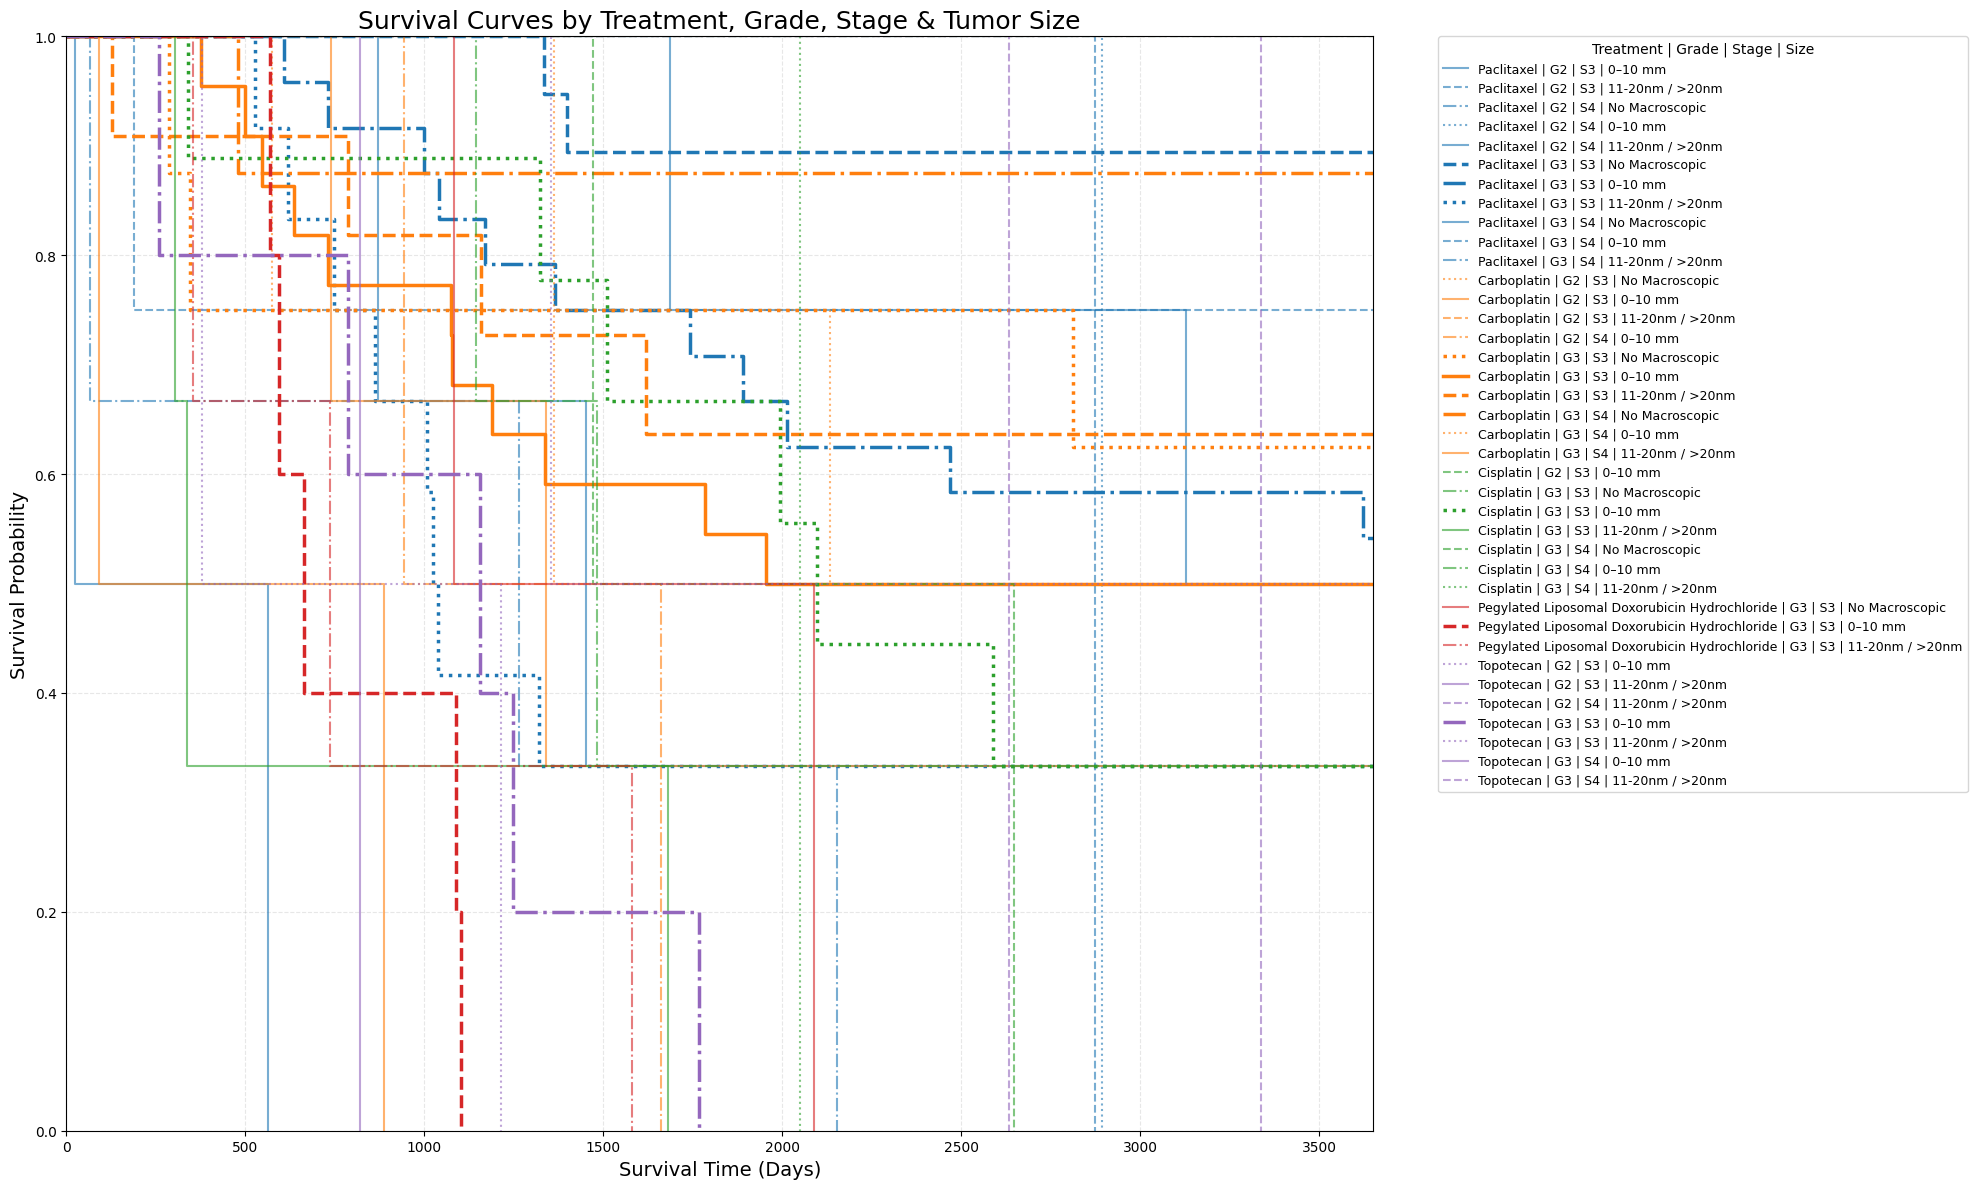

In [ ]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import numpy as np # Ensure numpy is imported

# Ensure df is defined, and survival_time + event columns exist in your df
# Example:
# df = df_final  # if you had a cleaned df_final before

selected_agents = ['Paclitaxel', 'Carboplatin', 'Cisplatin',
                   'Pegylated Liposomal Doxorubicin Hydrochloride', 'Topotecan']

plt.figure(figsize=(20, 12))
kmf = KaplanMeierFitter()

size_labels = {
    0: 'No Macroscopic',
    1: '0–10 mm',
    2: '11-20nm / >20nm',
}

color_map = {
    'Paclitaxel': '#1f77b4',
    'Carboplatin': '#ff7f0e',
    'Cisplatin': '#2ca02c',
    'Pegylated Liposomal Doxorubicin Hydrochloride': '#d62728',
    'Topotecan': '#9467bd'
}

linestyles = ['-', '--', '-.', ':']

# Counter to vary linestyles for clarity
style_counter = 0

# Convert pd.NA to np.nan in the columns used by lifelines just in case
df['survival_time'] = df['survival_time'].replace([pd.NA], np.nan)
df['event'] = df['event'].replace([pd.NA], np.nan).astype(float) # Convert event to float to handle np.nan

for treatment in selected_agents:
    for grade in [2, 3]:
        for stage in [3, 4]:
            for size in [ 0, 1, 2 ]:
                sub_df = df[
                    (df['treatments.therapeutic_agents'].str.lower().str.contains(treatment.lower(), na=False)) &
                    (df['grade'] == grade) &
                    (df['stage'] == stage) &
                    (df['size'] == size)
                ].copy() # Add .copy() to avoid SettingWithCopyWarning

                # Explicitly drop NaNs from the columns used by lifelines just before fitting
                sub_df.dropna(subset=['survival_time', 'event'], inplace=True)

                if len(sub_df) < 1:
                    continue

                # Ensure event column is integer type after dropping NaNs
                sub_df['event'] = sub_df['event'].astype(int)

                label = f"{treatment} | G{grade} | S{stage} | {size_labels[size]}"
                linestyle = linestyles[style_counter % len(linestyles)]

                kmf.fit(sub_df['survival_time'], event_observed=sub_df['event'], label=label)
                kmf.plot_survival_function(
                    ci_show=False,
                    color=color_map.get(treatment, None),
                    linewidth=2.5 if len(sub_df) >= 5 else 1.5,
                    linestyle=linestyle,
                    alpha=1 if len(sub_df) >= 5 else 0.6
                )
                style_counter += 1

plt.title('Survival Curves by Treatment, Grade, Stage & Tumor Size', fontsize=18)
plt.xlabel('Survival Time (Days)', fontsize=14)
plt.ylabel('Survival Probability', fontsize=14)
plt.xlim(0, 3650)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.3)

# Improve legend readability
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    title='Treatment | Grade | Stage | Size',
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 184 total observations, 88 right-censored observations>
         test_name = proportional_hazard_test

---
                                                              test_statistic    p  -log2(p)
grade                                                   km              0.36 0.55      0.86
                                                        rank            0.36 0.55      0.86
grade_size                                              km              0.00 0.98      0.03
                                                        rank            0.00 0.98      0.03
grade_stage                                             km              0.12 0.73      0.45
                                                        rank            0.12 0.73      0.45
size                                                    km              0.14 0.71      0.50
                                                        rank            0.14 0.71      0.50
stage                                                   km              0.00 0.96      0.06
                                                        rank            0.00 0.96      0.06
stage_size                                              km              0.13 0.72      0.47
                                                        rank            0.13 0.72      0.47
treatment_Cisplatin                                     km              3.74 0.05      4.24
                                                        rank            3.74 0.05      4.24
treatment_Paclitaxel                                    km              1.03 0.31      1.69
                                                        rank            1.03 0.31      1.69
treatment_Pegylated Liposomal Doxorubicin Hydrochloride km              2.51 0.11      3.14
                                                        rank            2.51 0.11      3.14
treatment_Topotecan                                     km              1.29 0.26      1.97
                                                        rank            1.29 0.26      1.97
treatment_paclitaxel                                    km              0.00 0.96      0.07
                                                        rank            0.00 0.96      0.07



1. Variable 'treatment_Cisplatin' failed the non-proportional test: p-value is 0.0530.

   Advice: with so few unique values (only 2), you can include `strata=['treatment_Cisplatin', ...]`
in the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification

Multivariable Cox Model with Interaction Terms
<lifelines.CoxPHFitter: fitted with 184 total observations

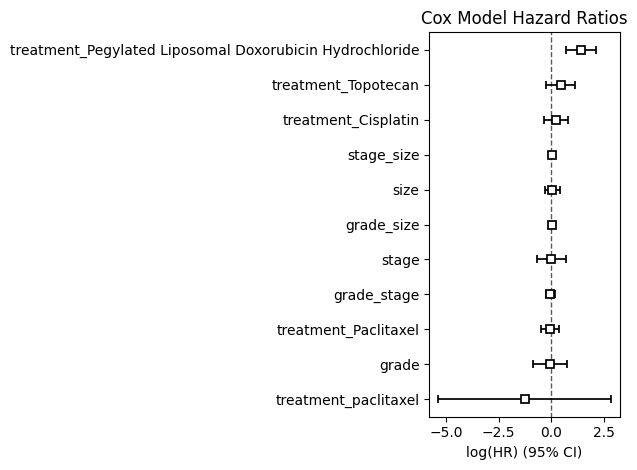

In [ ]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import re # Import the regex module for str.extract flags

# Load data
df = pd.read_excel('aibd-datset.xlsx')

# Filter for serous cystadenocarcinoma
df = df[df['diagnoses.primary_diagnosis'].str.contains(
    'serous cystadenocarcinoma', case=False, na=False)]

# Clean missing values BEFORE encoding or creating survival times
df.replace([
    "'--", "--", "unknown", "Not Reported",
    " ", "", "nan", "NaN", np.nan
], pd.NA, inplace=True)


# Encode clinical variables
# Use pd.NA handling for map
df['grade'] = df['diagnoses.tumor_grade'].str.upper().str.strip().map(
    {'G1':2, 'G2':2, 'G3':3, 'G4':2, 'GX':2, 'GB':2})


def encode_figo(stage):
    # Handle potential NA values from cleaning
    if pd.isna(stage):
        return pd.NA
    stage = str(stage).upper()
    return 3 if 'III' in stage else 4
df['stage'] = df['diagnoses.figo_stage'].apply(encode_figo)

size_map = {
    'NO MACROSCOPIC DISEASE':0,
    '1-10 MM':1,
    '11-20 MM':2,
    '>20 MM':3,
}
# Use pd.NA handling for map
df['size'] = df['pathology_details.residual_tumor_measurement'].str.upper().str.strip().map(size_map)


# Filter therapeutic agents
selected_agents = [
    'Paclitaxel',
    'Carboplatin',
    'Cisplatin',
    'Pegylated Liposomal Doxorubicin Hydrochloride',
    'Topotecan'
]
# Use str.extract with the non-capture group (?:...) to avoid creating extra columns
# Also, handle potential NA values in 'treatments.therapeutic_agents'
df['treatment'] = df['treatments.therapeutic_agents'].str.extract(
    f'({"|".join(selected_agents)})', flags=re.IGNORECASE, expand=False)


# Create survival variables using age_at_index as proxy for censoring
# Convert columns to numeric AFTER cleaning but BEFORE np.where
df['demographic.days_to_death'] = pd.to_numeric(df['demographic.days_to_death'], errors='coerce')
df['demographic.age_at_index'] = pd.to_numeric(df['demographic.age_at_index'], errors='coerce')

df['survival_time'] = np.where(
    df['demographic.vital_status'] == 'Dead',
    df['demographic.days_to_death'],
    df['demographic.age_at_index'] * 365  # Convert age to days
)
df['event'] = (df['demographic.vital_status'] == 'Dead').astype(int)

# Clean and prepare final dataset - .dropna will remove rows with NA in specified columns
cox_df = df[['survival_time', 'event', 'grade', 'stage', 'size', 'treatment']].dropna(subset=['survival_time', 'event', 'grade', 'stage', 'size', 'treatment'])

# Convert categorical 'treatment' to dummy variables
cox_df = pd.get_dummies(cox_df, columns=['treatment'], prefix='treatment', drop_first=True)

# Create interaction terms - ensure columns are numeric after get_dummies
# Drop original treatment column before creating interaction terms if not dropped by get_dummies
# Ensure columns used for interaction are numeric (they should be after encoding and get_dummies)
numeric_cols_for_interaction = ['grade', 'stage', 'size'] + [col for col in cox_df.columns if col.startswith('treatment_')]
for col in numeric_cols_for_interaction:
    cox_df[col] = pd.to_numeric(cox_df[col], errors='coerce')

# Drop rows with NaNs introduced by coerce if any
cox_df.dropna(subset=numeric_cols_for_interaction, inplace=True)


cox_df['grade_stage'] = cox_df['grade'] * cox_df['stage']
cox_df['grade_size'] = cox_df['grade'] * cox_df['size']
cox_df['stage_size'] = cox_df['stage'] * cox_df['size']

# Fit Cox model
cph = CoxPHFitter(penalizer=0.1)

# Ensure duration and event columns are correctly typed after dropna
cox_df['survival_time'] = pd.to_numeric(cox_df['survival_time'])
cox_df['event'] = cox_df['event'].astype(int)

cph.fit(cox_df, duration_col='survival_time', event_col='event')

# Check assumptions
# Note: check_assumptions can sometimes give warnings or errors if data is sparse or features are highly correlated.
# If it causes issues, you might temporarily comment it out for the model fitting part.
try:
    cph.check_assumptions(cox_df, p_value_threshold=0.05)
except Exception as e:
    print(f"Assumption check failed: {e}")


# Print results
print("Multivariable Cox Model with Interaction Terms")
cph.print_summary(decimals=3, style='ascii')

# Visualize effects
cph.plot()
plt.title('Cox Model Hazard Ratios')
plt.tight_layout()
plt.show() # Added plt.show() to display the plot